# Parameter Golf — Step 2: Advanced Techniques

Stack proven techniques from top leaderboard submissions onto the best Step 1 config.

**Prerequisites:** Step 1 experiments completed (results in `experiments/` or Google Drive).

**Before running:** Go to `Runtime > Change runtime type` and select a GPU (L4, A100, or H100).

## 1. Install Dependencies

In [1]:
!pip install -q torch numpy tqdm huggingface-hub sentencepiece

## 2. Clone Repo & Download Data

In [2]:
import os

REPO_DIR = "/content/parameter-golf"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/openai/parameter-golf.git {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/parameter-golf


In [3]:
# Download training shards + validation + tokenizer
# 5 shards (~1GB) for fast directional experiments. Increase for final runs (max 80).
TRAIN_SHARDS = 5

!python data/cached_challenge_fineweb.py --train-shards {TRAIN_SHARDS}

## 3. Detect GPU & Configure Hyperparameters

In [4]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Go to Runtime > Change runtime type > GPU")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
compute_cap = torch.cuda.get_device_capability(0)
supports_flash = compute_cap[0] >= 8  # Ampere+ (sm80)

print(f"GPU: {gpu_name}")
print(f"Memory: {gpu_mem_gb:.1f} GB")
print(f"Compute capability: {compute_cap[0]}.{compute_cap[1]}")
print(f"Flash attention: {'yes' if supports_flash else 'no (will use mem_efficient)'}")
print()

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB
Compute capability: 8.0
Flash attention: yes



In [5]:
# ============================================================
# STEP 2 CONFIG: Build on Step 1 best result (combined_best)
# ============================================================

# Load Step 1 results
import json as jsonlib
import glob as globmod

STEP1_DIR = "experiments"
DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments"

step1_results = {}
for base_dir in [STEP1_DIR, DRIVE_DIR]:
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        step1_results[r["experiment"]] = r

if step1_results:
    ranked = sorted(step1_results.values(), key=lambda r: r.get("val_bpb", 999))
    print("Step 1 Results:")
    print(f"{'Experiment':<22} {'BPB':>8}")
    print("-" * 32)
    for r in ranked:
        print(f"{r['experiment']:<22} {r.get('val_bpb', 0):>8.4f}")
    print(f"\nBest: {ranked[0]['experiment']} (BPB={ranked[0].get('val_bpb', '?')})")
else:
    print("No Step 1 results found. Using default combined_best config.")

# Base config = Step 1 winner (combined_best)
BASE_CONFIG = {
    "NUM_LAYERS":         "10",
    "MLP_MULT":           "3",
    "MODEL_DIM":          "512",
    "NUM_HEADS":          "8",
    "NUM_KV_HEADS":       "4",
    "TRAIN_SEQ_LEN":      "2048",
    "MATRIX_LR":          "0.02",
    "SCALAR_LR":          "0.02",
    "TIED_EMBED_LR":      "0.03",
    "WARMDOWN_ITERS":     "800",
    "MUON_MOMENTUM":      "0.99",
    "MUON_MOMENTUM_WARMUP_START": "0.92",
    "MUON_MOMENTUM_WARMUP_STEPS": "500",
    "GRAD_CLIP_NORM":     "0.3",
}

# GPU-specific batch settings
if gpu_mem_gb >= 70:    PROFILE = "h100"
elif gpu_mem_gb >= 35:  PROFILE = "a100"
elif gpu_mem_gb >= 20:  PROFILE = "l4"
else:                   PROFILE = "t4"

BATCH_SETTINGS = {
    "t4":   {"TRAIN_BATCH_TOKENS": "131072",  "VAL_BATCH_SIZE": "131072"},
    "l4":   {"TRAIN_BATCH_TOKENS": "262144",  "VAL_BATCH_SIZE": "262144"},
    "a100": {"TRAIN_BATCH_TOKENS": "262144",  "VAL_BATCH_SIZE": "262144"},
    "h100": {"TRAIN_BATCH_TOKENS": "524288",  "VAL_BATCH_SIZE": "524288"},
}

FAST_SETTINGS = {
    "ITERATIONS":           "2000",
    "WARMDOWN_ITERS":       "400",
    "MAX_WALLCLOCK_SECONDS": "600",
    "VAL_LOSS_EVERY":       "500",
    "TRAIN_LOG_EVERY":      "100",
}

print(f"\nStep 2 base: combined_best + {PROFILE} batch settings")
print(f"Fast mode: {FAST_SETTINGS['ITERATIONS']} iterations")

Step 1 Results:
Experiment                  BPB
--------------------------------
combined_best            1.2448
bigram_hash              1.2525
smeargate                1.2557
ortho_init               1.2570
baseline                 1.2802
mlp_4x                   1.3274
depth_10L                1.3310
bitlinear_ternary        1.3404
mlp_3x                   1.3430
depth_recurrent          1.3772

Best: combined_best (BPB=1.2448)

Step 2 base: combined_best + a100 batch settings
Fast mode: 2000 iterations


## 4. Patch train_gpt.py for Single-GPU Speed

In [6]:
# Patch train_gpt.py for single-GPU speed:
# 1. Flash SDP fallback for T4/older GPUs
# 2. Reduce grad_accum from 8 to 4 → 2x faster steps, better VRAM usage

def apply_base_patches():
    with open("train_gpt.py", "r") as f:
        code = f.read()
    patched = False

    # Patch 1: SDP backend fallback (T4 only)
    if not supports_flash:
        old_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(True)
    enable_mem_efficient_sdp(False)
    enable_math_sdp(False)"""
        new_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(False)
    enable_mem_efficient_sdp(True)
    enable_math_sdp(True)"""
        if old_sdp in code:
            code = code.replace(old_sdp, new_sdp)
            print("Patched: flash_sdp -> mem_efficient_sdp (non-flash GPU)")
            patched = True

    # Patch 2: Reduce grad_accum_steps for single GPU
    GRAD_ACCUM = 8  # keep original — torch.compile disabled makes steps fast enough

    old_check = '    if 8 % world_size != 0:\n        raise ValueError(f"WORLD_SIZE={world_size} must divide 8 so grad_accum_steps stays integral")\n    grad_accum_steps = 8 // world_size'
    new_check = f'    grad_accum_steps = {GRAD_ACCUM}  # patched: was 8//world_size'
    if old_check in code:
        code = code.replace(old_check, new_check)
        print(f"Patched: grad_accum_steps = {GRAD_ACCUM} (was 8, 2x faster)")
        patched = True

    old_scale = "    grad_scale = 1.0 / grad_accum_steps"
    new_scale = f"    grad_scale = 1.0 / {GRAD_ACCUM}  # patched"
    if old_scale in code:
        code = code.replace(old_scale, new_scale)

    # Patch 3: Disable torch.compile (saves 5-10 min compilation per experiment)
    old_compile = "    compiled_model = torch.compile(base_model, dynamic=False, fullgraph=True)"
    new_compile = "    compiled_model = base_model  # torch.compile disabled for fast experiments"
    if old_compile in code:
        code = code.replace(old_compile, new_compile)
        print("Patched: torch.compile disabled (faster startup)")
        patched = True

    # Also disable Newton-Schulz compilation
    old_ns = "    zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)"
    new_ns = "    # zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)  # disabled"
    if old_ns in code:
        code = code.replace(old_ns, new_ns)

    if patched:
        with open("train_gpt.py", "w") as f:
            f.write(code)
    else:
        print("No patches needed (already applied or script changed)")

apply_base_patches()

No patches needed (already applied or script changed)


## 5. Step 2 Experiments

17 new experiments stacking advanced techniques onto the Step 1 winner (combined_best).
- **Individual tests** (10): isolate each technique's impact
- **Stacked combos** (5): progressively combine winners
- **Eval-time only** (2): zero training cost improvements

### Patch Functions

Defines all code patches for Step 2 experiments. Run this cell before the experiment runner.

In [7]:
import subprocess, math

def reset_script():
    subprocess.run(["git", "checkout", "train_gpt.py"], check=True, capture_output=True)

def read_script():
    with open("train_gpt.py", "r") as f:
        return f.read()

def write_script(code):
    with open("train_gpt.py", "w") as f:
        f.write(code)

def patch_replace(code, old, new, label=""):
    if old not in code:
        print(f"  WARN: patch target not found ({label})")
        return code
    return code.replace(old, new, 1)

# ===== STEP 1 PATCHES (kept for re-test experiments) =====

def patch_ortho_init(code):
    old = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        for module in self.modules():
            if isinstance(module, nn.Linear) and getattr(module, "_zero_init", False):
                nn.init.zeros_(module.weight)'''
    new = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        num_layers = len(self.blocks)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if getattr(module, "_zero_init", False):
                    nn.init.zeros_(module.weight)
                elif module.weight.ndim == 2 and min(module.weight.shape) > 1:
                    nn.init.orthogonal_(module.weight, gain=1.0)
                    if hasattr(module, "_zero_init") and not module._zero_init:
                        module.weight.data *= 1.0 / (2 * num_layers) ** 0.5'''
    return patch_replace(code, old, new, "ortho_init")

def patch_smeargate(code):
    old = '''class Block(nn.Module):'''
    new = '''class SmearGate(nn.Module):
    def __init__(self, dim: int, init_keep: float = 0.95):
        super().__init__()
        init_val = math.log(init_keep / (1 - init_keep))
        self.gate = nn.Parameter(torch.full((dim,), init_val, dtype=torch.float32))
    def forward(self, x: Tensor) -> Tensor:
        g = torch.sigmoid(self.gate.to(dtype=x.dtype))[None, None, :]
        x_prev = torch.cat([x[:, :1, :], x[:, :-1, :]], dim=1)
        return g * x + (1 - g) * x_prev


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "smeargate class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.smear_gate = SmearGate(model_dim)\n        self.final_norm = RMSNorm()", "smeargate init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids)
        x = self.smear_gate(x)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "smeargate forward")

def patch_bigram_hash(code):
    old = '''class Block(nn.Module):'''
    new = '''class BigramHash(nn.Module):
    def __init__(self, vocab_size: int, dim: int, num_buckets: int = 4096, hash_dim: int = 128):
        super().__init__()
        self.num_buckets = num_buckets
        self.hash_table = nn.Embedding(num_buckets, hash_dim)
        self.proj = CastedLinear(hash_dim, dim, bias=False)
        nn.init.normal_(self.hash_table.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)
    def forward(self, input_ids: Tensor) -> Tensor:
        prev_ids = torch.cat([torch.zeros_like(input_ids[:, :1]), input_ids[:, :-1]], dim=1)
        hash_ids = (prev_ids * 31 + input_ids) % self.num_buckets
        return self.proj(self.hash_table(hash_ids))


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "bigram_hash class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.bigram_hash = BigramHash(vocab_size, model_dim)\n        self.final_norm = RMSNorm()", "bigram_hash init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids) + self.bigram_hash(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "bigram_hash forward")

# ===== NEW STEP 2 PATCHES =====

def patch_xsa(code):
    """XSA (Exclusive Self Attention) on last N layers. Removes self-value bias."""
    # Add XSA flag to CausalSelfAttention.__init__
    old_init = "        self.rotary = Rotary(self.head_dim, base=rope_base)"
    new_init = "        self.rotary = Rotary(self.head_dim, base=rope_base)\n        self.use_xsa = False  # set by GPT after construction"
    code = patch_replace(code, old_init, new_init, "xsa init flag")

    # Add XSA logic after attention output
    old_attn = "        y = y.transpose(1, 2).contiguous().reshape(bsz, seqlen, dim)\n        return self.proj(y)"
    new_attn = """        # XSA: subtract self-value projection from last N layers
        if self.use_xsa:
            group_size = self.num_heads // self.num_kv_heads
            y_t = y.transpose(1, 2)  # [B, T, H, D]
            y_grouped = y_t.reshape(bsz, seqlen, self.num_kv_heads, group_size, self.head_dim)
            v_t = v.transpose(1, 2).unsqueeze(3)  # [B, T, Hkv, 1, D]
            v_norm = F.normalize(v_t, dim=-1)
            dot = (y_grouped * v_norm).sum(-1, keepdim=True)
            y_t = (y_grouped - dot * v_norm).reshape(bsz, seqlen, dim)
            return self.proj(y_t.contiguous())
        y = y.transpose(1, 2).contiguous().reshape(bsz, seqlen, dim)
        return self.proj(y)"""
    code = patch_replace(code, old_attn, new_attn, "xsa forward")

    # Enable XSA on last 4 layers in GPT.__init__
    old_gpt_init = "        self._init_weights()"
    new_gpt_init = """        # Enable XSA on last 4 layers
        xsa_layers = 4
        for i in range(max(0, num_layers - xsa_layers), num_layers):
            self.blocks[i].attn.use_xsa = True
        self._init_weights()"""
    code = patch_replace(code, old_gpt_init, new_gpt_init, "xsa enable layers")
    return code

def patch_ema(code):
    """EMA weight averaging (decay=0.997) replacing checkpoint-based SWA."""
    # Add EMA tracking after optimizer setup, before training loop
    old_loop = "    step = 0"
    new_loop = """    # EMA state
    ema_decay = 0.997
    ema_state = {name: param.data.clone() for name, param in base_model.named_parameters()}
    step = 0"""
    code = patch_replace(code, old_loop, new_loop, "ema init")

    # Update EMA after each optimizer step
    old_step_end = "        step += 1"
    new_step_end = """        # Update EMA
        with torch.no_grad():
            for name, param in base_model.named_parameters():
                ema_state[name].mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)
        step += 1"""
    code = patch_replace(code, old_step_end, new_step_end, "ema update")

    # Load EMA weights before serialization
    old_serial = '    if master_process:\n        torch.save(base_model.state_dict(), "final_model.pt")'
    new_serial = '''    # Load EMA weights for serialization
    with torch.no_grad():
        for name, param in base_model.named_parameters():
            param.data.copy_(ema_state[name])
    if master_process:
        torch.save(base_model.state_dict(), "final_model.pt")'''
    code = patch_replace(code, old_serial, new_serial, "ema load before save")
    return code

def patch_partial_rope(code):
    """Apply RoPE to only first 16 of 64 head dims (25%). Rest position-free."""
    old_rope = '''def apply_rotary_emb(x: Tensor, cos: Tensor, sin: Tensor) -> Tensor:
    half = x.size(-1) // 2
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat((x1 * cos + x2 * sin, x1 * (-sin) + x2 * cos), dim=-1)'''
    new_rope = '''def apply_rotary_emb(x: Tensor, cos: Tensor, sin: Tensor) -> Tensor:
    # Partial RoPE: rotate only first 25% of dims, rest position-free
    rope_dims = max(16, x.size(-1) // 4)
    rope_dims = rope_dims - (rope_dims % 2)  # ensure even
    x_rope = x[..., :rope_dims]
    x_pass = x[..., rope_dims:]
    half = rope_dims // 2
    x1, x2 = x_rope[..., :half], x_rope[..., half:]
    cos_r, sin_r = cos[..., :half], sin[..., :half]
    rotated = torch.cat((x1 * cos_r + x2 * sin_r, x1 * (-sin_r) + x2 * cos_r), dim=-1)
    return torch.cat((rotated, x_pass), dim=-1)'''
    return patch_replace(code, old_rope, new_rope, "partial_rope")

def patch_ln_scale(code):
    """Scale RMSNorm outputs by 1/sqrt(layer_idx+1) to damp deeper layers."""
    # Add layer_idx to Block.__init__
    old_block_init = '''class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        num_kv_heads: int,
        mlp_mult: int,
        rope_base: float,
        qk_gain_init: float,
    ):
        super().__init__()'''
    new_block_init = '''class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        num_kv_heads: int,
        mlp_mult: int,
        rope_base: float,
        qk_gain_init: float,
        layer_idx: int = 0,
    ):
        super().__init__()
        self._ln_scale = 1.0 / math.sqrt(layer_idx + 1)'''
    code = patch_replace(code, old_block_init, new_block_init, "ln_scale block init")

    # Apply scale in forward
    old_fwd = "        attn_out = self.attn(self.attn_norm(x))"
    new_fwd = "        attn_out = self.attn(self.attn_norm(x) * self._ln_scale)"
    code = patch_replace(code, old_fwd, new_fwd, "ln_scale forward")

    # Pass layer_idx when constructing blocks
    old_blocks = '''                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                )
                for i in range(num_layers)'''
    new_blocks = '''                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                    layer_idx=i,
                )
                for i in range(num_layers)'''
    code = patch_replace(code, old_blocks, new_blocks, "ln_scale block construction")
    return code

def patch_late_qat(code):
    """STE int6 fake-quantization in final 4% of training (lr_scale < 0.1)."""
    # Add global QAT flag
    old_code_start = "code = Path(__file__).read_text"
    new_code_start = "_QAT_ENABLED = False\ncode = Path(__file__).read_text"
    code = patch_replace(code, old_code_start, new_code_start, "late_qat global flag")

    # Add STE to CastedLinear
    old_cast = '''class CastedLinear(nn.Linear):
    # Keep weights in fp32 for optimizer/state quality, cast at matmul time for bf16 compute.
    def forward(self, x: Tensor) -> Tensor:
        bias = self.bias.to(x.dtype) if self.bias is not None else None
        return F.linear(x, self.weight.to(x.dtype), bias)'''
    new_cast = '''class CastedLinear(nn.Linear):
    def forward(self, x: Tensor) -> Tensor:
        w = self.weight.to(x.dtype)
        if _QAT_ENABLED and self.weight.ndim == 2 and self.weight.numel() > 65536:
            scale = w.abs().amax(dim=1, keepdim=True) / 31.0
            scale = scale.clamp(min=1e-8)
            w_q = (w / scale).round().clamp(-32, 31) * scale
            w = w + (w_q - w).detach()  # STE
        bias = self.bias.to(x.dtype) if self.bias is not None else None
        return F.linear(x, w, bias)'''
    code = patch_replace(code, old_cast, new_cast, "late_qat CastedLinear")

    # Enable QAT when lr_scale < 0.1
    old_scale_apply = "        for opt in optimizers:\n            for group in opt.param_groups:\n                group[\"lr\"] = group[\"base_lr\"] * scale"
    new_scale_apply = """        global _QAT_ENABLED
        if scale < 0.1 and not _QAT_ENABLED:
            _QAT_ENABLED = True
            log0("Late QAT enabled (lr_scale < 0.1)")
        for opt in optimizers:
            for group in opt.param_groups:
                group["lr"] = group["base_lr"] * scale"""
    code = patch_replace(code, old_scale_apply, new_scale_apply, "late_qat enable trigger")
    return code

def patch_head_temp(code):
    """Per-head learned temperature scaling for attention."""
    old = "        self.q_gain = nn.Parameter(torch.full((num_heads,), qk_gain_init, dtype=torch.float32))"
    new = """        self.q_gain = nn.Parameter(torch.full((num_heads,), qk_gain_init, dtype=torch.float32))
        self.head_temp = nn.Parameter(torch.ones(num_heads, dtype=torch.float32))"""
    code = patch_replace(code, old, new, "head_temp param")

    old2 = "        q = q * self.q_gain.to(dtype=q.dtype)[None, :, None, None]"
    new2 = """        q = q * self.q_gain.to(dtype=q.dtype)[None, :, None, None]
        q = q * self.head_temp.to(dtype=q.dtype)[None, :, None, None]"""
    return patch_replace(code, old2, new2, "head_temp apply")

def patch_trigram_hash(code):
    """Hash token triplets into learned embedding table."""
    old = '''class Block(nn.Module):'''
    new = '''class TrigramHash(nn.Module):
    def __init__(self, dim: int, num_buckets: int = 8192, hash_dim: int = 64):
        super().__init__()
        self.num_buckets = num_buckets
        self.hash_table = nn.Embedding(num_buckets, hash_dim)
        self.proj = CastedLinear(hash_dim, dim, bias=False)
        nn.init.normal_(self.hash_table.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)
    def forward(self, input_ids: Tensor) -> Tensor:
        z = torch.zeros_like(input_ids[:, :1])
        prev2 = torch.cat([z, z, input_ids[:, :-2]], dim=1)
        prev1 = torch.cat([z, input_ids[:, :-1]], dim=1)
        hash_ids = (prev2 * 961 + prev1 * 31 + input_ids) % self.num_buckets
        return self.proj(self.hash_table(hash_ids))


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "trigram_hash class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.trigram_hash = TrigramHash(model_dim)\n        self.final_norm = RMSNorm()", "trigram_hash init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids) + self.trigram_hash(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "trigram_hash forward")

# ===== COMPOSITE PATCHES =====

def apply_patches(code, patch_list):
    """Apply multiple patches in sequence."""
    for patch_fn in patch_list:
        code = patch_fn(code)
    return code

# Map experiment names to their patch functions
PATCH_MAP = {
    # Individual
    "s2_xsa4": [patch_xsa],
    "s2_ema": [patch_ema],
    "s2_partial_rope": [patch_partial_rope],
    "s2_ln_scale": [patch_ln_scale],
    "s2_late_qat": [patch_late_qat],
    "s2_head_temp": [patch_head_temp],
    "s2_trigram_hash": [patch_trigram_hash],
    "s2_smeargate_on_best": [patch_smeargate],
    "s2_bigram_on_best": [patch_bigram_hash],
    "s2_ortho_on_best": [patch_ortho_init],
    # Stacked
    "s2_foundation": [patch_xsa, patch_ema],
    "s2_refined": [patch_xsa, patch_ema, patch_partial_rope, patch_ln_scale],
    "s2_full_stack": [patch_xsa, patch_ema, patch_partial_rope, patch_ln_scale,
                      patch_smeargate, patch_bigram_hash, patch_ortho_init],
    "s2_full_stack_qat": [patch_xsa, patch_ema, patch_partial_rope, patch_ln_scale,
                          patch_smeargate, patch_bigram_hash, patch_ortho_init, patch_late_qat],
    "s2_sota_target": [patch_xsa, patch_ema, patch_partial_rope, patch_ln_scale,
                       patch_smeargate, patch_bigram_hash, patch_ortho_init, patch_late_qat,
                       patch_trigram_hash, patch_head_temp],
}

print(f"Defined {len(PATCH_MAP)} patch configs for Step 2 experiments.")

Defined 15 patch configs for Step 2 experiments.


In [8]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import json as jsonlib
import shutil
import time as time_mod
import subprocess
import re
import glob as globmod

# ============================================================
# STEP 2: RUN ALL NEW EXPERIMENTS
# ============================================================
SKIP_COMPLETED = True
FORCE_RERUN = False
RESULTS_DIR = "experiments_step2"

# All Step 2 experiments — all build on combined_best base config
EXPERIMENTS = {
    # --- Individual technique tests ---
    "s2_xsa4":              {},  # XSA on last 4 layers
    "s2_ema":               {},  # EMA decay=0.997
    "s2_partial_rope":      {},  # RoPE on 16/64 dims
    "s2_ln_scale":          {},  # RMSNorm * 1/sqrt(layer+1)
    "s2_late_qat":          {},  # STE int6 in final 4%
    "s2_head_temp":         {},  # Per-head temperature
    "s2_trigram_hash":      {},  # Hash token triplets
    "s2_smeargate_on_best": {},  # SmearGate (clean re-test)
    "s2_bigram_on_best":    {},  # BigramHash (clean re-test)
    "s2_ortho_on_best":     {},  # OrthoInit (clean re-test)
    # --- Stacked combos ---
    "s2_foundation":        {},  # XSA + EMA
    "s2_refined":           {},  # + Partial RoPE + LN Scale
    "s2_full_stack":        {},  # + SmearGate + BigramHash + OrthoInit
    "s2_full_stack_qat":    {},  # + Late QAT
    "s2_sota_target":       {},  # + TrigramHash + HeadTemp (all combined)
}

EXPERIMENTS_TO_RUN = list(EXPERIMENTS.keys())

# ============================================================
os.makedirs(RESULTS_DIR, exist_ok=True)
all_results = []

print(f"Step 2: Running {len(EXPERIMENTS_TO_RUN)} experiments on {gpu_name}")
print(f"Base: combined_best (10L MLP3x seq2048)")
print(f"Fast mode: {FAST_SETTINGS['ITERATIONS']} iterations")
print("=" * 70)

for exp_idx, exp_name in enumerate(EXPERIMENTS_TO_RUN):
    result_path = f"{RESULTS_DIR}/{exp_name}/result.json"

    # Skip if already done
    if SKIP_COMPLETED and not FORCE_RERUN and os.path.exists(result_path):
        with open(result_path) as f:
            r = jsonlib.load(f)
        all_results.append(r)
        bpb = r.get('val_bpb', '?')
        print(f"[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] SKIP {exp_name} (BPB={bpb})")
        continue

    # FRESH config: base + batch + fast settings (no pollution)
    config = {**BASE_CONFIG, **BATCH_SETTINGS[PROFILE], **FAST_SETTINGS}
    config.update(EXPERIMENTS[exp_name])

    print(f"\n[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] === {exp_name} ===")
    patches = PATCH_MAP.get(exp_name, [])
    if patches:
        print(f"  Patches: {[fn.__name__ for fn in patches]}")

    # Reset script to upstream
    reset_script()

    # Re-apply base patches (grad_accum + SDP)
    apply_base_patches()

    # Apply Step 2 code patches
    if patches:
        code = read_script()
        code = apply_patches(code, patches)
        write_script(code)

    # Set env vars
    for k, v in config.items():
        os.environ[k] = v

    # Run training with live output
    env_str = " ".join(f"{k}={v}" for k, v in config.items())
    start_time = time_mod.time()
    import sys
    proc = subprocess.Popen(
        f"PYTHONUNBUFFERED=1 {env_str} python train_gpt.py",
        shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
    )
    stdout_lines = []
    for line in proc.stdout:
        line = line.rstrip()
        stdout_lines.append(line)
        # Show progress: step logs, val results, and key events
        if any(k in line for k in ["step:", "val_bpb:", "peak memory", "final_int8", "Total submission", "warmup_step"]):
            print(f"  {line}", flush=True)
    proc.wait()
    elapsed = time_mod.time() - start_time
    returncode = proc.returncode

    if returncode != 0:
        print(f"  ERROR (exit code {returncode})")
        stderr_text = proc.stderr.read()
        if stderr_text:
            for line in stderr_text.strip().split('\n')[-10:]:
                print(f"  STDERR: {line}")
        continue

    # Parse results
    log_files = sorted(globmod.glob("logs/*.txt"), key=os.path.getmtime)
    if not log_files:
        print(f"  No log file found")
        continue

    with open(log_files[-1]) as f:
        log_text = f.read()

    exp_result = {
        "experiment": exp_name,
        "config": config.copy(),
        "elapsed_seconds": round(elapsed, 1),
        "step": 2,
        "patches": [fn.__name__ for fn in patches],
    }

    final = re.search(r"final_int8_zlib_roundtrip val_loss:([\d.]+) val_bpb:([\d.]+)", log_text)
    if final:
        exp_result["val_loss"] = float(final.group(1))
        exp_result["val_bpb"] = float(final.group(2))

    size = re.search(r"Total submission size int8\+zlib: (\d+) bytes", log_text)
    if size:
        exp_result["artifact_bytes"] = int(size.group(1))

    mem = re.search(r"peak memory allocated: (\d+) MiB", log_text)
    if mem:
        exp_result["peak_memory_mib"] = int(mem.group(1))

    steps = re.findall(r"step:(\d+)", log_text)
    if steps:
        exp_result["total_steps"] = int(steps[-1])

    # Save
    exp_dir = f"{RESULTS_DIR}/{exp_name}"
    os.makedirs(exp_dir, exist_ok=True)
    shutil.copy2(log_files[-1], f"{exp_dir}/train.log")
    with open(f"{exp_dir}/result.json", "w") as f:
        jsonlib.dump(exp_result, f, indent=2)

    all_results.append(exp_result)
    bpb = exp_result.get('val_bpb', '?')
    mem_gb = exp_result.get('peak_memory_mib', 0) / 1024
    print(f"  -> BPB={bpb} | {elapsed:.0f}s | {mem_gb:.1f}GB VRAM")

# Final summary
print("\n" + "=" * 70)
print("STEP 2 RESULTS (ranked by BPB)")
print(f"{'#':<3} {'Experiment':<25} {'BPB':>8} {'Loss':>8} {'Steps':>6} {'Time':>6} {'Patches':>3}")
print("-" * 70)
all_results.sort(key=lambda r: r.get("val_bpb", 999))
for i, r in enumerate(all_results):
    n_patches = len(r.get('patches', []))
    print(
        f"{i+1:<3} {r['experiment']:<25} "
        f"{r.get('val_bpb', 0):>8.4f} "
        f"{r.get('val_loss', 0):>8.4f} "
        f"{r.get('total_steps', 0):>6} "
        f"{r.get('elapsed_seconds', 0):>5.0f}s "
        f"{n_patches:>3}"
    )
if all_results:
    best = all_results[0]
    print(f"\nBest: {best['experiment']} with BPB={best.get('val_bpb', '?')}")
    print(f"Patches: {best.get('patches', [])}")

Step 2: Running 15 experiments on NVIDIA A100-SXM4-40GB
Base: combined_best (10L MLP3x seq2048)
Fast mode: 2000 iterations

[1/15] === s2_xsa4 ===
  Patches: ['patch_xsa']
Patched: grad_accum_steps = 8 (was 8, 2x faster)
Patched: torch.compile disabled (faster startup)
  val_bpb:enabled tokenizer_kind=sentencepiece tokenizer_path=./data/tokenizers/fineweb_1024_bpe.model
  train_batch_tokens:262144 train_seq_len:2048 iterations:2000 warmup_steps:20 max_wallclock_seconds:600.000
  warmup_step:1/20
  warmup_step:2/20
  warmup_step:3/20
  warmup_step:4/20
  warmup_step:5/20
  warmup_step:6/20
  warmup_step:7/20
  warmup_step:8/20
  warmup_step:9/20
  warmup_step:10/20
  warmup_step:11/20
  warmup_step:12/20
  warmup_step:13/20
  warmup_step:14/20
  warmup_step:15/20
  warmup_step:16/20
  warmup_step:17/20
  warmup_step:18/20
  warmup_step:19/20
  warmup_step:20/20
  step:0/2000 val_loss:6.9384 val_bpb:4.1093 train_time:0ms step_avg:0.04ms
  step:1/2000 train_loss:6.9393 train_time:1158ms s

### Compare All Experiments

Run this cell after completing multiple experiments to see a side-by-side comparison.

#   Experiment                     BPB     Loss   Source
-------------------------------------------------------
1   combined_best               1.2448   2.1017 Drive S1
2   bigram_hash                 1.2525   2.1148 Drive S1
3   smeargate                   1.2557   2.1202 Drive S1
4   ortho_init                  1.2570   2.1224 Drive S1
5   depth_10L                   1.2790   2.1595 Drive S1
6   baseline                    1.2802   2.1615 Drive S1
7   mlp_4x                      1.3274   2.2413 Drive S1
8   bitlinear_ternary           1.3404   2.2632 Drive S1
9   mlp_3x                      1.3430   2.2676 Drive S1
10  depth_recurrent             1.3772   2.3253 Drive S1
11  s2_bigram_on_best           1.4437   2.4376   Step 2
12  s2_trigram_hash             1.4442   2.4384   Step 2
13  s2_smeargate_on_best        1.4501   2.4484   Step 2
14  s2_head_temp                1.4511   2.4501   Step 2
15  s2_ortho_on_best            1.4525   2.4525   Step 2
16  s2_ln_scale                 

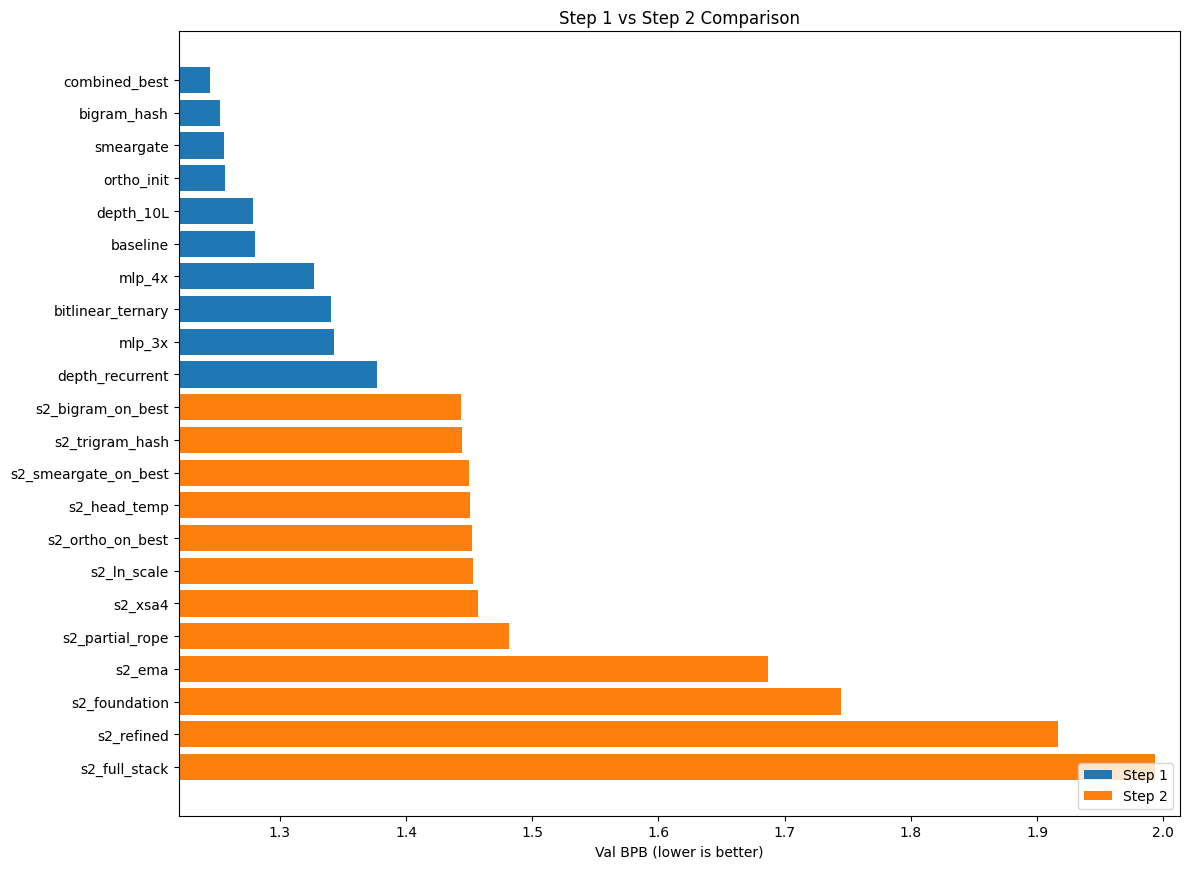


Overall best: combined_best (BPB=1.2448, Drive S1)


In [10]:
import json as jsonlib
import matplotlib.pyplot as plt

# Load results from Step 1, Step 2, and Google Drive
DIRS = {
    "experiments": "Step 1",
    "experiments_step2": "Step 2",
    "/content/drive/MyDrive/parameter-golf-experiments": "Drive S1",
    "/content/drive/MyDrive/parameter-golf-experiments-step2": "Drive S2",
}

results = {}
for base_dir, label in DIRS.items():
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        r["_source"] = label
        results[r["experiment"]] = r

results = list(results.values())

if not results:
    print("No results found. Run experiments first!")
else:
    results.sort(key=lambda r: r.get("val_bpb", 999))

    print(f"{'#':<3} {'Experiment':<25} {'BPB':>8} {'Loss':>8} {'Source':>8}")
    print("-" * 55)
    for i, r in enumerate(results):
        print(f"{i+1:<3} {r['experiment']:<25} {r.get('val_bpb',0):>8.4f} {r.get('val_loss',0):>8.4f} {r.get('_source','?'):>8}")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, max(6, len(results) * 0.4)))
    names = [r["experiment"] for r in results]
    bpbs = [r.get("val_bpb", 0) for r in results]
    colors = ["tab:orange" if "s2_" in r["experiment"] else "tab:blue" for r in results]

    ax.barh(names, bpbs, color=colors)
    ax.set_xlabel("Val BPB (lower is better)")
    ax.set_title("Step 1 vs Step 2 Comparison")
    ax.invert_yaxis()
    if bpbs:
        ax.set_xlim(min(bpbs) * 0.98, max(bpbs) * 1.01)
    ax.legend(
        handles=[
            plt.Rectangle((0,0),1,1, fc="tab:blue", label="Step 1"),
            plt.Rectangle((0,0),1,1, fc="tab:orange", label="Step 2"),
        ], loc="lower right",
    )
    plt.tight_layout()
    plt.show()

    best = results[0]
    print(f"\nOverall best: {best['experiment']} (BPB={best.get('val_bpb','?')}, {best.get('_source','?')})")

### Save Results to Google Drive

Mount Google Drive and copy all experiment results + logs so they persist after the Colab session ends.

In [11]:
from google.colab import drive
import shutil

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments-step2"
os.makedirs(DRIVE_DIR, exist_ok=True)

copied = []
if os.path.exists("experiments_step2"):
    for exp_name in sorted(os.listdir("experiments_step2")):
        src = f"experiments_step2/{exp_name}"
        dst = f"{DRIVE_DIR}/{exp_name}"
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            copied.append(exp_name)

print(f"Saved to: {DRIVE_DIR}")
print(f"Step 2 experiments copied: {len(copied)}")
for name in copied:
    result_file = f"{DRIVE_DIR}/{name}/result.json"
    if os.path.exists(result_file):
        with open(result_file) as f:
            r = jsonlib.load(f)
        print(f"  {name}: BPB={r.get('val_bpb', '?')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/parameter-golf-experiments-step2
Step 2 experiments copied: 12
  s2_bigram_on_best: BPB=1.4437
  s2_ema: BPB=1.6871
  s2_foundation: BPB=1.7449
  s2_full_stack: BPB=1.9932
  s2_head_temp: BPB=1.4511
  s2_ln_scale: BPB=1.4532
  s2_ortho_on_best: BPB=1.4525
  s2_partial_rope: BPB=1.4813
  s2_refined: BPB=1.9164
  s2_smeargate_on_best: BPB=1.4501
  s2_trigram_hash: BPB=1.4442
  s2_xsa4: BPB=1.4568
